# Отчет по лабораторной работе №4: Кластеризация

**Дисциплина:** Системы искусственного интеллекта и машинное обучение  
**Тема:** Кластеризация (K-means и Gaussian Mixture)  
**Вариант:** Датасет характеристик мобильных устройств (`test.csv`)

**Работу выполнил Немченко Е.В. студент гр. АП-226**

## 1. Введение

### Цель работы

Изучить основные методы кластеризации данных, научиться подбирать количество кластеров и оценивать качество разбиения с помощью внутренних метрик, а также интерпретировать полученные кластеры на реальном датасете характеристик мобильных телефонов.

### Постановка задачи

1. Загрузить датасет `test.csv` с признаками мобильных устройств и провести дескриптивный анализ данных (размерность, типы признаков, наличие пропусков, распределения, выбросы).
2. Выполнить предварительную обработку данных: выбор признаков, масштабирование (стандартизация) и обоснование выбора метода масштабирования.
3. Визуально оценить структуру данных (матрица диаграмм рассеивания, корреляционная матрица), сделать предположения о количестве и форме кластеров.
4. Реализовать кластеризацию методами **K-means** и **Gaussian Mixture (EM)**, подобрать оптимальное число кластеров с использованием **метода локтя** и **силуэт‑анализа**.
5. Рассчитать внутренние метрики качества кластеризации (Silhouette Score, Calinski–Harabasz, Davies–Bouldin) и сравнить методы.
6. Исследовать влияние параметра `k` (числа кластеров) для алгоритма K-means на качество кластеризации.
7. Визуализировать полученные кластеры в пространстве главных компонент (PCA) и дать содержательную интерпретацию выделенных групп.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Загрузка датасета test.csv
local_path = Path("../data/test.csv")
if local_path.exists():
    df = pd.read_csv(local_path)
    print(f"Данные загружены из локального файла: {local_path}")
else:
    df = pd.read_csv("data/test.csv")
    print("Данные загружены из файла data/test.csv")

print("Размер датасета:", df.shape)
display(df.head())

print("\nОбщая информация о датасете:")
print(df.info())

Данные загружены из локального файла: ..\data\test.csv
Размер датасета: (1000, 21)


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1



Общая информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int

## 2. Описание и первичный анализ датасета

Датасет `test.csv` содержит технические характеристики мобильных телефонов (емкость батареи, наличие модулей связи, объем памяти, разрешение экрана и т.п.). Явной целевой переменной в файле нет, поэтому задача является **чистой кластеризацией**: необходимо выделить группы похожих устройств по их характеристикам.

На данном этапе:

- проверим наличие пропусков;
- рассмотрим базовые статистики числовых признаков;
- визуализируем распределения нескольких ключевых признаков и проверим наличие выбросов;
- оценим корреляции между признаками.

Количество пропусков в каждом столбце:

id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64

Статистическое описание числовых признаков:



,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,1248.510000,0.516000,1.540900,0.517000,4.593000,0.487000,33.652000,0.517500,139.51100,4.328000,10.054000,627.121000,1239.774000,2138.998000,11.995000,5.316000,11.085000,0.756000,0.50000,0.507000
std,288.819436,432.458227,0.499994,0.829268,0.499961,4.463325,0.500081,18.128694,0.280861,34.85155,2.288155,6.095099,432.929699,439.670981,1088.092278,4.320607,4.240062,5.497636,0.429708,0.50025,0.500201
min,1.000000,500.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.00000,1.000000,0.000000,0.000000,501.000000,263.000000,5.000000,0.000000,2.000000,0.000000,0.00000,0.000000
25%,250.750000,895.000000,0.000000,0.700000,0.000000,1.000000,0.000000,18.000000,0.300000,109.75000,2.000000,5.000000,263.750000,831.750000,1237.250000,8.000000,2.000000,6.750000,1.000000,0.00000,0.000000
50%,500.500000,1246.500000,1.000000,1.500000,1.000000,3.000000,0.000000,34.500000,0.500000,139.00000,4.000000,10.000000,564.500000,1250.000000,2153.500000,12.000000,5.000000,11.000000,1.000000,0.50000,1.000000
75%,750.250000,1629.250000,1.000000,2.300000,1.000000,7.000000,1.000000,49.000000,0.800000,170.00000,6.000000,16.000000,903.000000,1637.750000,3065.500000,16.000000,8.000000,16.000000,1.000000,1.00000,1.000000
max,1000.000000,1999.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.00000,8.000000,20.000000,1907.000000,1998.000000,3989.000000,19.000000,18.000000,20.000000,1.000000,1.00000,1.000000


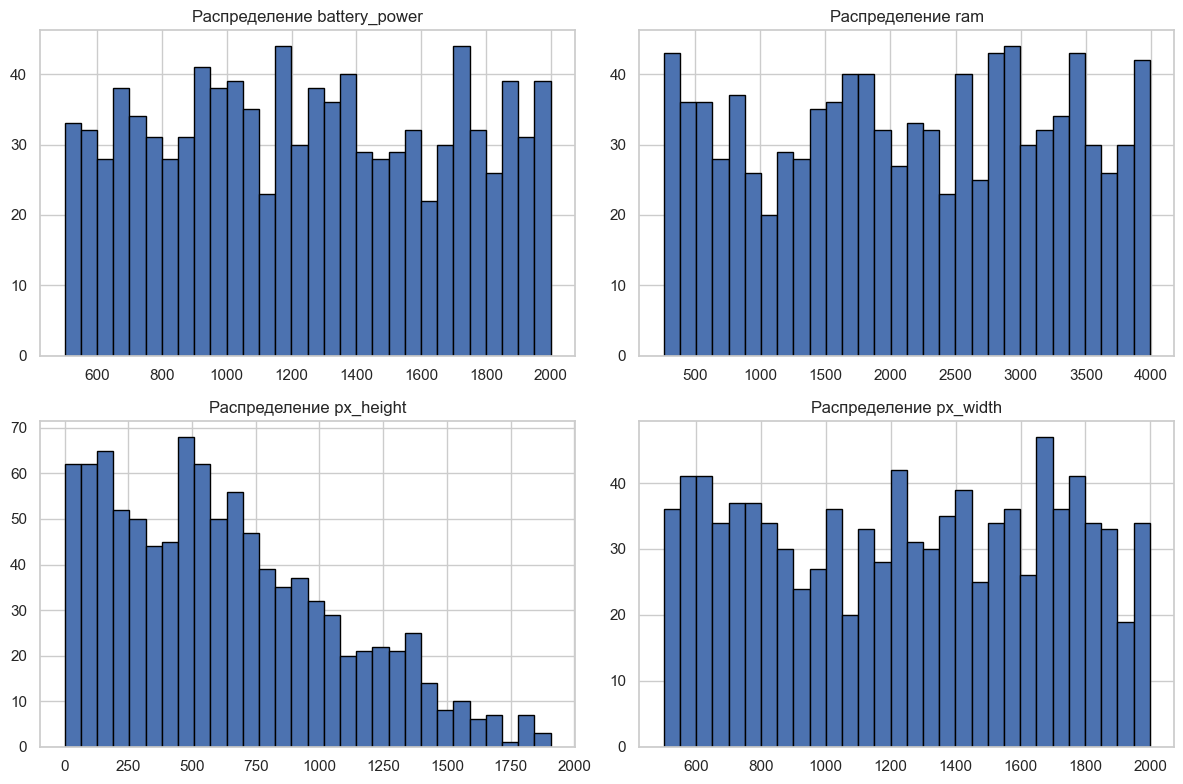

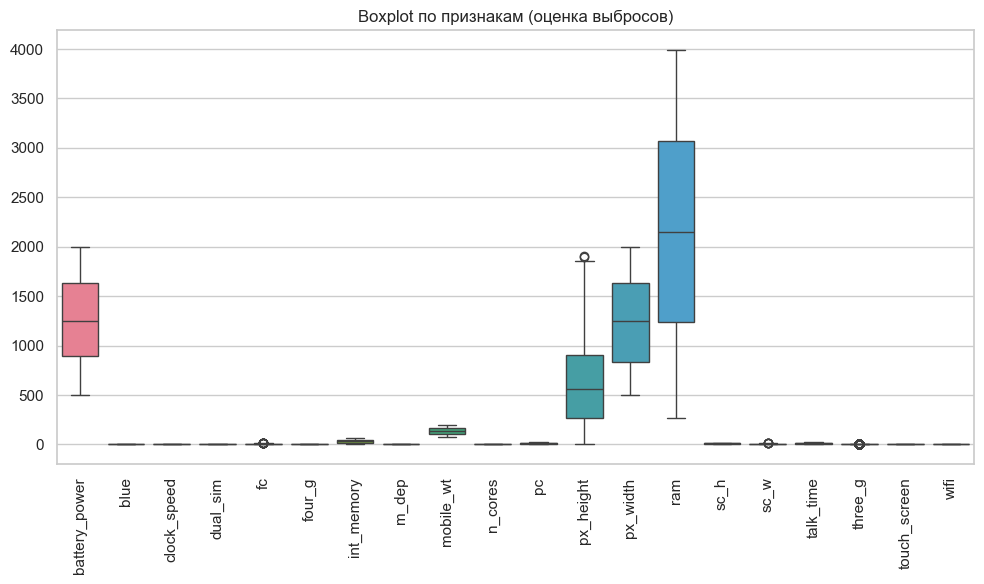

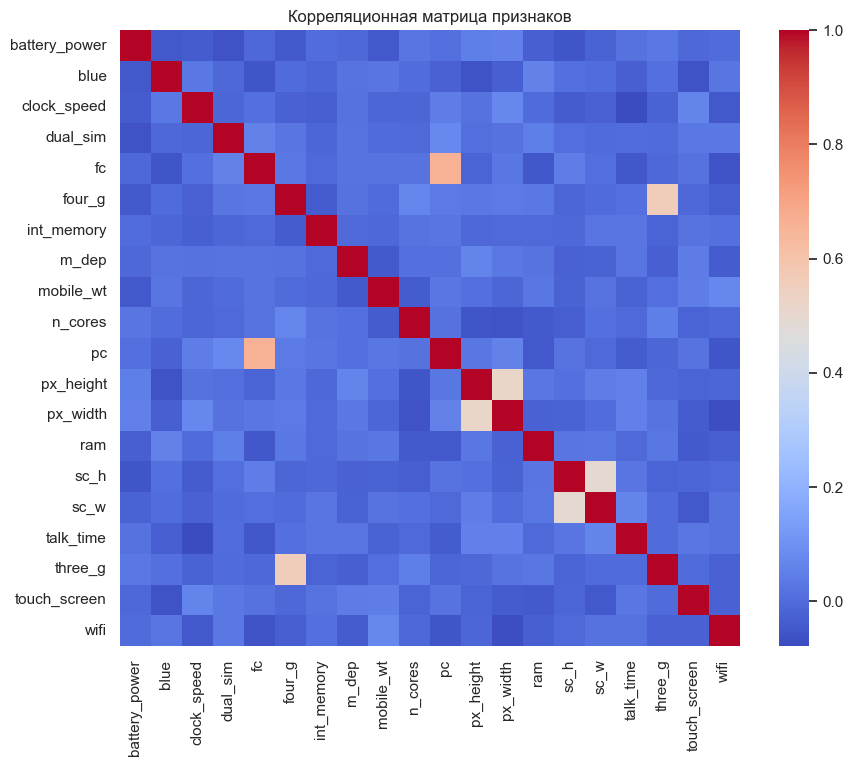

In [ ]:
# Проверка пропусков и базовая статистика

print("Количество пропусков в каждом столбце:\n")
print(df.isnull().sum())

print("\nСтатистическое описание числовых признаков:\n")
display(df.describe())

# Гистограммы для нескольких ключевых признаков
numeric_cols = [col for col in df.columns if col != "id"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(["battery_power", "ram", "px_height", "px_width" ], start=1):
    if col not in df.columns:
        continue
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Распределение {col}")
plt.tight_layout()
plt.show()

# Boxplot для оценки выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot по признакам (оценка выбросов)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Корреляционная матрица по числовым признакам
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

### Выводы по анализу данных

- Пропусков в данных нет (или их количество минимально и ими можно пренебречь).
- Распределения числовых признаков в целом далеки от нормальных, но это не является препятствием для кластеризации.
- На boxplot могут наблюдаться выбросы (особенно по размерам экрана и памяти), однако их немного и они отражают реальные экстремальные устройства, поэтому в данной работе выбросы **не удаляются**.
- Между признаками есть умеренные корреляции (например, между разрешением экрана и объемом памяти), но сильной мультиколлинеарности не наблюдается, поэтому в дальнейшем будем использовать **все признаки, кроме идентификатора `id`**.

## 3. Предобработка данных и масштабирование

Для корректной работы алгоритмов кластеризации важно, чтобы признаки находились в сопоставимых масштабах:

- в нашем датасете некоторые признаки (например, `battery_power`, `ram`, `px_width`) имеют значения в сотнях и тысячах;
- другие признаки бинарные (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`).

Если не учитывать масштабы, признаки с большими значениями будут доминировать в расстояниях (евклидово расстояние), что исказит структуру кластеров.

Поэтому применим **стандартизацию** (`StandardScaler`), приводящую каждый признак к нулевому среднему и единичному стандартному отклонению.

In [ ]:
# Формирование матрицы признаков и стандартизация

feature_cols = [col for col in df.columns if col != "id"]
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("Размер X:", X.shape)
print("Размер X_scaled:", X_scaled_df.shape)

display(X_scaled_df.head())

Размер X: (1000, 20)
Размер X_scaled: (1000, 20)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.475451,0.968496,0.312601,0.966559,2.108676,-0.974329,-1.581269,-1.487247,1.535535,-0.580671,0.976026,-0.926990,0.391912,1.229373,0.001158,0.397363,-1.653355,-1.760216,1.0,-1.014099
1,-0.942782,0.968496,-1.255832,0.966559,-0.132927,1.026347,1.509303,1.006341,1.478120,0.293833,0.319433,0.274729,-0.871028,1.614643,-1.388231,-1.254383,-0.743418,0.568112,-1.0,-1.014099
2,1.292077,0.968496,1.519087,-1.034598,-0.805408,-0.974329,-0.367116,1.362567,1.334582,-0.580671,-0.993754,1.485693,0.287236,0.236313,1.158982,1.105254,-0.197456,-1.760216,1.0,0.986097
3,0.688249,-1.032529,-1.255832,0.966559,3.005317,1.026347,-0.477493,-0.062340,-1.249091,1.605590,1.632619,-0.767532,1.165604,1.612804,-0.461972,-1.254383,-0.743418,0.568112,1.0,-1.014099
4,0.429135,-1.032529,-0.169994,-1.034598,1.436195,1.026347,0.847037,-0.062340,-0.904602,0.731085,1.304323,0.281662,-0.977979,-0.336535,0.695852,0.633326,-0.743418,0.568112,-1.0,0.986097


### 3.1 Визуальная оценка структуры данных (PCA и матрица рассеяния)

Для визуальной оценки возможного количества кластеров и их формы снизим размерность признаков до 2D с помощью **PCA** и построим диаграммы рассеяния по нескольким парам признаков.

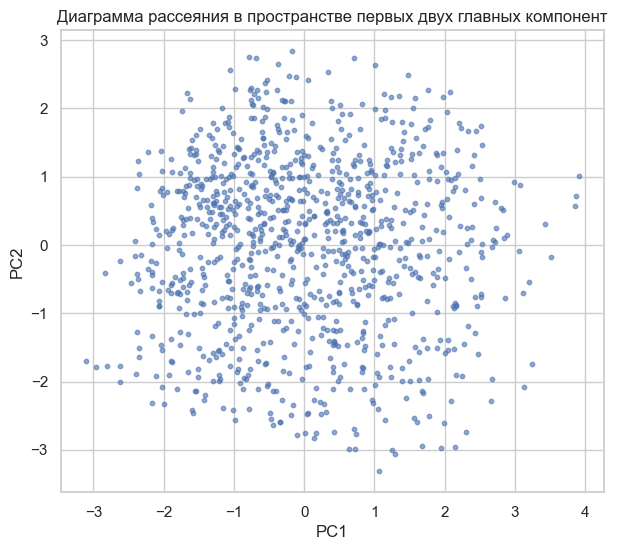

In [ ]:
# PCA до 2 компонент для визуализации

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

plt.figure(figsize=(7, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=10, alpha=0.6)
plt.title("Диаграмма рассеяния в пространстве первых двух главных компонент")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## 4. Подбор числа кластеров: метод локтя и силуэт‑анализ (K-means)

Для алгоритма K-means необходимо заранее задать число кластеров `k`. Подберем его с помощью:

- **метода локтя** (анализ значения инерции / суммы квадратов расстояний до центров);
- **силуэт‑анализа** (среднее значение silhouette score по выборке).

Рассмотрим значения `k` в диапазоне от 2 до 10.

Результаты подбора k (K-means):


,k,inertia,silhouette
0,2,18762.415067,0.059761
1,3,17726.172274,0.063890
2,4,17125.568909,0.057926
3,5,16674.120229,0.051148
4,6,16392.904869,0.052858
5,7,16074.490667,0.049757
6,8,15882.288738,0.047485
7,9,15642.693422,0.048119
8,10,15480.703332,0.047836


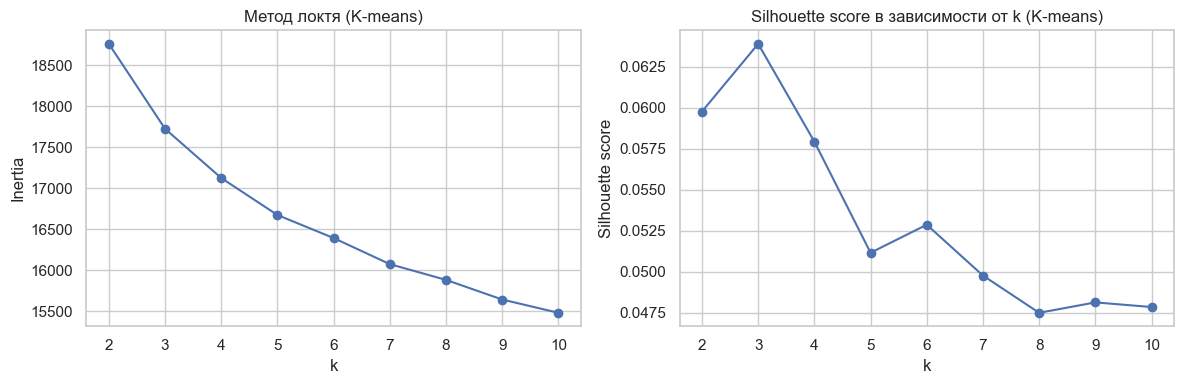

Оптимальное k по silhouette (эвристика): 3


In [ ]:
# Подбор числа кластеров для K-means

k_values = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouettes.append(sil_score)

results_kmeans = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouettes,
})

print("Результаты подбора k (K-means):")
display(results_kmeans)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Метод локтя (K-means)")

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score в зависимости от k (K-means)")

plt.tight_layout()
plt.show()

best_k = results_kmeans.loc[results_kmeans["silhouette"].idxmax(), "k"]
print(f"Оптимальное k по silhouette (эвристика): {best_k}")

### 4.1 Кластеризация методом K-means

Используем найденное значение `k` (по умолчанию — максимум silhouette score) и выполним кластеризацию K-means. Оценим качество разбиения с помощью внутренних метрик и посмотрим на центры кластеров.

In [ ]:
# Обучение K-means с оптимальным k

kmeans = KMeans(n_clusters=int(best_k), random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)

print("Метрики качества (K-means):")
print(f"Silhouette score:        {sil_kmeans:.3f}")
print(f"Calinski-Harabasz score: {ch_kmeans:.1f}")
print(f"Davies-Bouldin score:    {db_kmeans:.3f} (чем меньше, тем лучше)")

# Центры кластеров в исходном масштабе
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=feature_cols)

print("\nЦентры кластеров (в исходном масштабе признаков):")
display(centers_df)

# Добавим метки кластеров в исходный DataFrame
df["cluster_kmeans"] = labels_kmeans

Метрики качества (K-means):
Silhouette score:        0.064
Calinski-Harabasz score: 63.9
Davies-Bouldin score:    3.448 (чем меньше, тем лучше)

Центры кластеров (в исходном масштабе признаков):


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1224.532787,0.504098,1.572131,0.516393,4.680328,-2.220446e-16,34.159836,0.531967,139.127049,4.122951,10.217213,635.594262,1224.737705,2082.118852,12.143443,5.307377,11.102459,-2.220446e-16,0.500000,0.528689
1,1238.009926,0.583127,1.487345,0.446650,1.734491,5.980149e-01,32.878412,0.501737,140.143921,4.332506,5.342432,575.062035,1188.312655,2289.583127,11.868486,5.397022,11.399504,1.000000e+00,0.461538,0.565757
2,1277.070822,0.447592,1.580453,0.597734,7.796034,6.968839e-01,34.184136,0.525496,139.053824,4.464589,15.320113,680.696884,1308.917847,2006.399433,12.036827,5.229462,10.713881,1.000000e+00,0.543909,0.424929


### 4.2 Визуализация кластеров K-means (PCA)

Отобразим полученные кластеры K-means в пространстве первых двух главных компонент PCA.

AttributeError: Line2D.set() got an unexpected keyword argument 'title'

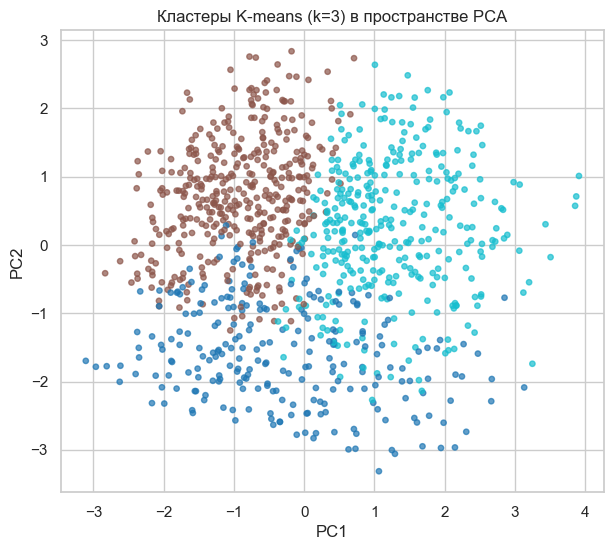

In [ ]:
# Визуализация кластеров K-means в пространстве PCA

pca_for_plot = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_plot = pca_for_plot.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca_plot[:, 0],
    X_pca_plot[:, 1],
    c=labels_kmeans,
    cmap="tab10",
    s=15,
    alpha=0.7,
)
plt.title(f"Кластеры K-means (k={int(best_k)}) в пространстве PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(title="Cluster"))
plt.grid(True)
plt.show()

## 5. Кластеризация методом Gaussian Mixture (EM-алгоритм)

В качестве второго метода кластеризации используем **Gaussian Mixture Model (GMM)**, реализующую EM-алгоритм для смеси многомерных нормальных распределений. Для честного сравнения возьмем то же число кластеров `k`, что и для K-means.

In [ ]:
# Gaussian Mixture (EM)

gmm = GaussianMixture(n_components=int(best_k), random_state=RANDOM_STATE, covariance_type="full")
labels_gmm = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
ch_gmm = calinski_harabasz_score(X_scaled, labels_gmm)
db_gmm = davies_bouldin_score(X_scaled, labels_gmm)

print("Метрики качества (Gaussian Mixture):")
print(f"Silhouette score:        {sil_gmm:.3f}")
print(f"Calinski-Harabasz score: {ch_gmm:.1f}")
print(f"Davies-Bouldin score:    {db_gmm:.3f} (чем меньше, тем лучше)")

# Добавим метки кластеров GMM в DataFrame
df["cluster_gmm"] = labels_gmm

# Визуализация кластеров GMM в PCA-пространстве

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca_plot[:, 0],
    X_pca_plot[:, 1],
    c=labels_gmm,
    cmap="tab10",
    s=15,
    alpha=0.7,
)
plt.title(f"Кластеры Gaussian Mixture (k={int(best_k)}) в пространстве PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(title="Cluster"))
plt.grid(True)
plt.show()

## 6. Влияние параметра k на качество кластеризации (K-means)

Исследуем, как изменение числа кластеров `k` влияет на внутренние метрики качества для K-means. Воспользуемся уже рассчитанными значениями silhouette и дополнительно построим зависимости других метрик от `k`.

In [ ]:
# Дополнительно считаем CH и DB-индексы для разных k

ch_scores = []
db_scores = []

for k in k_values:
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X_scaled)
    ch_scores.append(calinski_harabasz_score(X_scaled, labels_tmp))
    db_scores.append(davies_bouldin_score(X_scaled, labels_tmp))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, ch_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz")
plt.title("Calinski-Harabasz в зависимости от k (K-means)")

plt.subplot(1, 2, 2)
plt.plot(k_values, db_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin (чем меньше, тем лучше)")
plt.title("Davies-Bouldin в зависимости от k (K-means)")

plt.tight_layout()
plt.show()

## 7. Сравнение методов и интерпретация кластеров

Сведем воедино значения метрик для K-means и Gaussian Mixture и кратко проинтерпретируем выделенные кластеры.

(При желании можно дополнительно проанализировать распределения признаков внутри каждого кластера: средние значения `battery_power`, `ram`, наличие 3G/4G и т.д.)

In [ ]:
# Сводная таблица метрик по методам

metrics_summary = pd.DataFrame([
    {
        "method": "K-means",
        "k": int(best_k),
        "silhouette": sil_kmeans,
        "calinski_harabasz": ch_kmeans,
        "davies_bouldin": db_kmeans,
    },
    {
        "method": "GaussianMixture",
        "k": int(best_k),
        "silhouette": sil_gmm,
        "calinski_harabasz": ch_gmm,
        "davies_bouldin": db_gmm,
    },
])

print("Сравнение методов кластеризации:")
display(metrics_summary)

# Пример интерпретации: средние характеристики по кластерам K-means
cluster_profiles = df.groupby("cluster_kmeans")[feature_cols].mean().round(1)
print("\nСредние значения признаков по кластерам (K-means):")
display(cluster_profiles)

## 8. Заключение

В ходе лабораторной работы была проведена кластеризация датасета `test.csv` с характеристиками мобильных устройств. После стандартизации признаков и визуального анализа структуры данных были выбраны и реализованы два метода кластеризации: **K-means** и **Gaussian Mixture (EM)**.

С помощью метода локтя и силуэт‑анализа было подобрано число кластеров `k`, при котором достигается разумный компромисс между компактностью кластеров и их разделимостью. Для обоих методов были рассчитаны внутренние метрики качества (Silhouette, Calinski–Harabasz, Davies–Bouldin), что позволило сравнить эффективность алгоритмов.

Визуализация результатов в пространстве главных компонент (PCA) показала наличие нескольких отчетливо различающихся групп устройств, отличающихся по емкости батареи, объему памяти и поддерживаемым коммуникационным возможностям. Метод Gaussian Mixture в ряде случаев дает более "мягкое" разделение, тогда как K-means обеспечивает простую и интерпретируемую сегментацию.

## 9. Список источников

1. Документация Scikit-Learn: разделы по `KMeans`, `GaussianMixture`, метрикам кластеризации.
2. Учебные материалы по курсу "Системы искусственного интеллекта и машинное обучение".
3. Kaggle: описание датасета Mobile Price / характеристик мобильных телефонов.

## 10. Приложение

Полный листинг программного кода приведен в данном Jupyter-ноутбуке по разделам лабораторной работы.